In [57]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
import time
import copy
from torchvision import models
import pandas as pd
import seaborn as sns
import os
from torchsummary import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


Number of train samples: 50000
Number of test samples: 10000


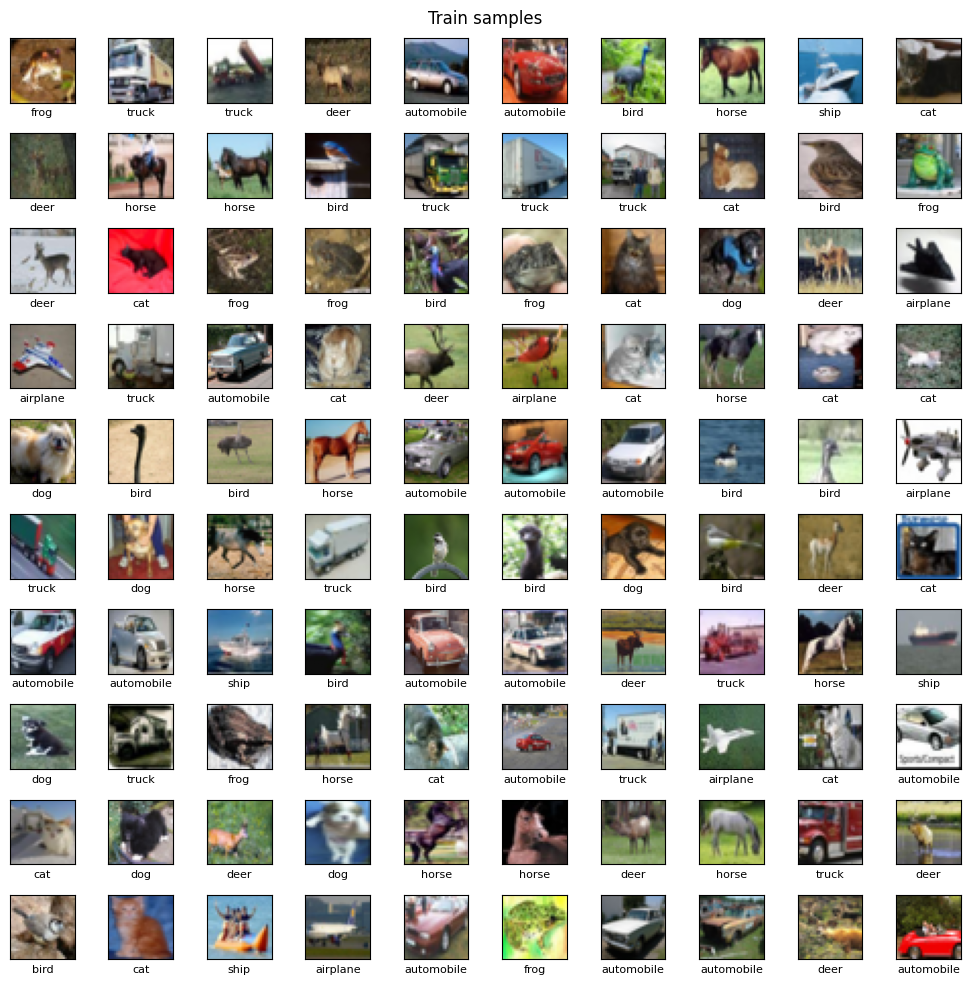

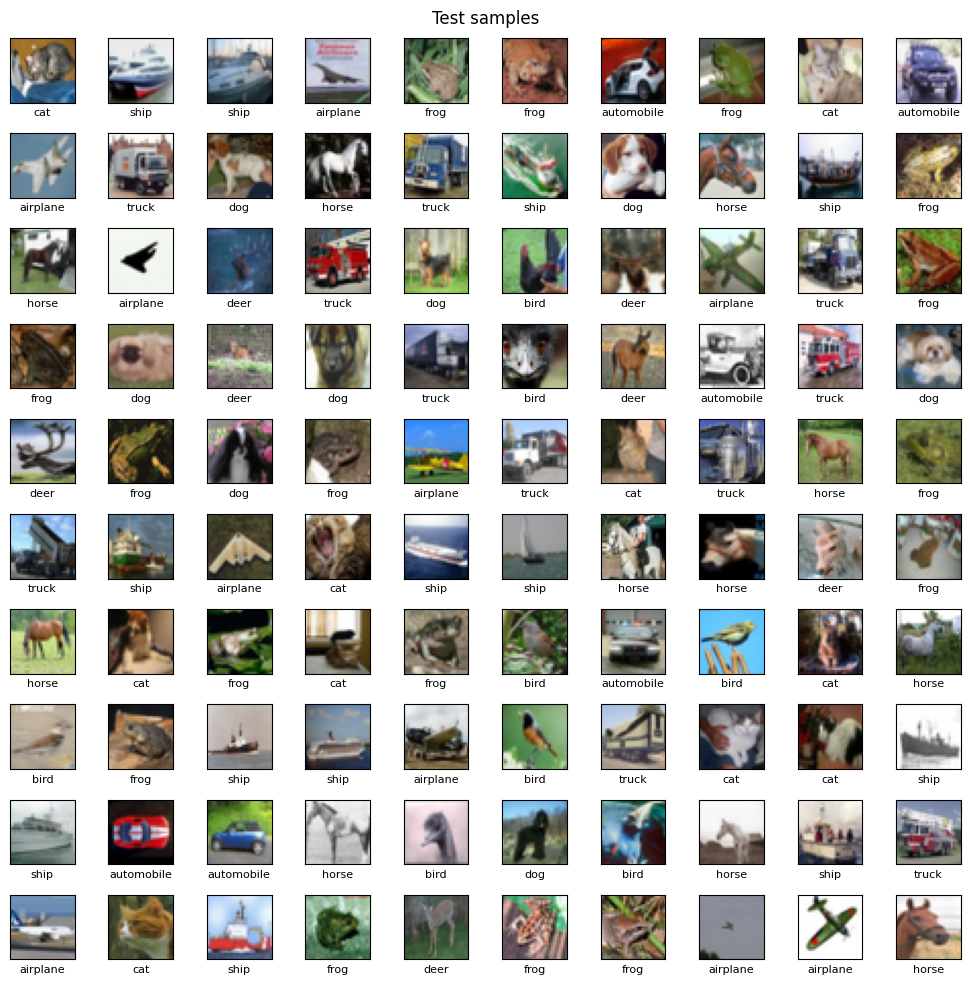

In [58]:
dir_name = os.getcwd()
batch_size = 100

def show_images(dataset, title):
    num_showed_imgs_x = 10
    num_showed_imgs_y = 10

    figsize = (10, 10)
    fig, axes = plt.subplots(num_showed_imgs_y, num_showed_imgs_x, figsize = figsize)
    fig.suptitle(title)
    if dataset and hasattr(dataset, 'classes'):
        classes = dataset.classes

    plt.setp(plt.gcf().get_axes(), xticks=[], yticks=[])
    for i, ax in enumerate(axes.flat):
        if i < len(dataset):
            img = dataset[i][0].numpy().transpose(1, 2, 0)
            label_idx = dataset[i][1]

            if isinstance(label_idx, (int, np.integer)) and label_idx < len(classes):
                label_name = classes[label_idx]
            else:
                label_name = str(label_idx)

            ax.imshow(img)
            ax.set_xlabel(label_name, fontsize=8)

    fig.tight_layout()


train_dataset = torchvision.datasets.CIFAR10(root = dir_name, train = True, download = True,
                                           transform = torchvision.transforms.ToTensor())
test_dataset = torchvision.datasets.CIFAR10(root = dir_name, train = False, download = True,
                                          transform = torchvision.transforms.ToTensor())

print(f'Number of train samples: {len(train_dataset)}')
show_images(train_dataset, 'Train samples')

print(f'Number of test samples: {len(test_dataset)}')
show_images(test_dataset, 'Test samples')

train_data_loader = torch.utils.data.DataLoader(train_dataset, batch_size = batch_size,
                                                shuffle = True)
test_data_loader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size,
                                               shuffle = False)

In [59]:
def create_resnet18(freeze_backbone=True):
    """Создает модель ResNet18 с модифицированным классификатором"""
    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, 10)

    if freeze_backbone:
        for name, param in model.named_parameters():
            if 'fc' not in name:
                param.requires_grad = False

    return model

def create_mobilenet_v2(freeze_backbone=True):
    """Создает модель MobileNetV2 с модифицированным классификатором"""
    model = models.mobilenet_v2(pretrained=True)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 10)

    if freeze_backbone:
        for name, param in model.named_parameters():
            if 'classifier' not in name:
                param.requires_grad = False

    return model

def create_efficientnet_b0(freeze_backbone=True):
    """Создает модель EfficientNet-B0 с модифицированным классификатором"""
    model = models.efficientnet_b0(pretrained=True)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 10)

    if freeze_backbone:
        for name, param in model.named_parameters():
            if 'classifier' not in name:
                param.requires_grad = False

    return model

def create_vgg16(freeze_backbone=True):
    """Создает модель VGG16 с модифицированным классификатором"""
    model = models.vgg16(pretrained=True)
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, 10)

    if freeze_backbone:
        for name, param in model.named_parameters():
            if 'classifier' not in name:
                param.requires_grad = False

    return model


In [60]:
def train_model(model, trainloader, criterion, optimizer, num_epochs=10):
    """Функция для обучения модели"""
    model.train()

    for epoch in range(num_epochs):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(trainloader)
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:}')

def test_model(model, testloader):
    """Функция для тестирования модели"""
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

def count_trainable_parameters(model):
    """Подсчет обучаемых параметров"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [61]:
print("=" * 60)
print("ЭКСПЕРИМЕНТ 1: Обучение только классификатора")
print("=" * 60)

experiment1_results = []
models_exp1 = {
    'ResNet18': create_resnet18(freeze_backbone=True),
    'MobileNetV2': create_mobilenet_v2(freeze_backbone=True),
    'EfficientNet-B0': create_efficientnet_b0(freeze_backbone=True),
    'VGG16': create_vgg16(freeze_backbone=True)
}

for model_name, model in models_exp1.items():
    print(f"\n--- Обучение {model_name} (только классификатор) ---")

    model = model.to(device)

    print(f"Архитектура: {model_name}")
    summary(model, input_size=(3, 32, 32))
    print("Слои классификатора:")
    if hasattr(model, 'fc'):
        print(f"  FC layers: {model.fc}")
    if hasattr(model, 'classifier'):
        print(f"  Classifier: {model.classifier}")

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.1)

    print(f"Оптимизатор: {optimizer}")
    print(f"Инициализация весов: предобученные веса backbone, случайные для классификатора")

    start_time = time.time()
    train_model(model, train_data_loader, criterion, optimizer, num_epochs=10)
    training_time = time.time() - start_time

    accuracy = test_model(model, test_data_loader)

    experiment1_results.append({
        'model': model_name,
        'experiment_type': 'classifier',
        'accuracy': accuracy,
        'trainable_params': count_trainable_parameters(model),
        'training_time': training_time
    })

    print(f"Точность на тестовой выборке: {accuracy}%")
    print(f"Время обучения: {training_time} секунд")

ЭКСПЕРИМЕНТ 1: Обучение только классификатора

--- Обучение ResNet18 (только классификатор) ---
Архитектура: ResNet18
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 16, 16]           9,408
       BatchNorm2d-2           [-1, 64, 16, 16]             128
              ReLU-3           [-1, 64, 16, 16]               0
         MaxPool2d-4             [-1, 64, 8, 8]               0
            Conv2d-5             [-1, 64, 8, 8]          36,864
       BatchNorm2d-6             [-1, 64, 8, 8]             128
              ReLU-7             [-1, 64, 8, 8]               0
            Conv2d-8             [-1, 64, 8, 8]          36,864
       BatchNorm2d-9             [-1, 64, 8, 8]             128
             ReLU-10             [-1, 64, 8, 8]               0
       BasicBlock-11             [-1, 64, 8, 8]               0
           Conv2d-12             [-1, 64, 8, 8]  

In [62]:
print("\n" + "=" * 60)
print("ЭКСПЕРИМЕНТ 2: Полное обучение сети")
print("=" * 60)

experiment2_results = []
models_exp2 = {
    'ResNet18': create_resnet18(freeze_backbone=False),
    'MobileNetV2': create_mobilenet_v2(freeze_backbone=False),
    'EfficientNet-B0': create_efficientnet_b0(freeze_backbone=False),
    'VGG16': create_vgg16(freeze_backbone=False)
}

for model_name, model in models_exp2.items():
    print(f"\n--- Полное обучение {model_name} ---")

    model = model.to(device)

    print(f"Архитектура: {model_name}")
    summary(model, input_size=(3, 32, 32))

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.1) if model_name != 'VGG16' else optim.SGD(model.parameters(), lr=0.01)

    print(f"Оптимизатор: {optimizer}")

    start_time = time.time()
    train_model(model, train_data_loader, criterion, optimizer, num_epochs=10)
    training_time = time.time() - start_time

    accuracy = test_model(model, test_data_loader)

    experiment2_results.append({
        'model': model_name,
        'experiment_type': 'total',
        'accuracy': accuracy,
        'trainable_params': count_trainable_parameters(model),
        'training_time': training_time
    })

    print(f"Точность на тестовой выборке: {accuracy}%")
    print(f"Время обучения: {training_time} секунд")


ЭКСПЕРИМЕНТ 2: Полное обучение сети

--- Полное обучение ResNet18 ---
Архитектура: ResNet18
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 16, 16]           9,408
       BatchNorm2d-2           [-1, 64, 16, 16]             128
              ReLU-3           [-1, 64, 16, 16]               0
         MaxPool2d-4             [-1, 64, 8, 8]               0
            Conv2d-5             [-1, 64, 8, 8]          36,864
       BatchNorm2d-6             [-1, 64, 8, 8]             128
              ReLU-7             [-1, 64, 8, 8]               0
            Conv2d-8             [-1, 64, 8, 8]          36,864
       BatchNorm2d-9             [-1, 64, 8, 8]             128
             ReLU-10             [-1, 64, 8, 8]               0
       BasicBlock-11             [-1, 64, 8, 8]               0
           Conv2d-12             [-1, 64, 8, 8]          36,864
      Batc


СРАВНИТЕЛЬНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ

Топ-4 модели по точности:
VGG16 (total): 86.77%
EfficientNet-B0 (total): 83.18%
ResNet18 (total): 77.67%
VGG16 (classifier): 63.18%


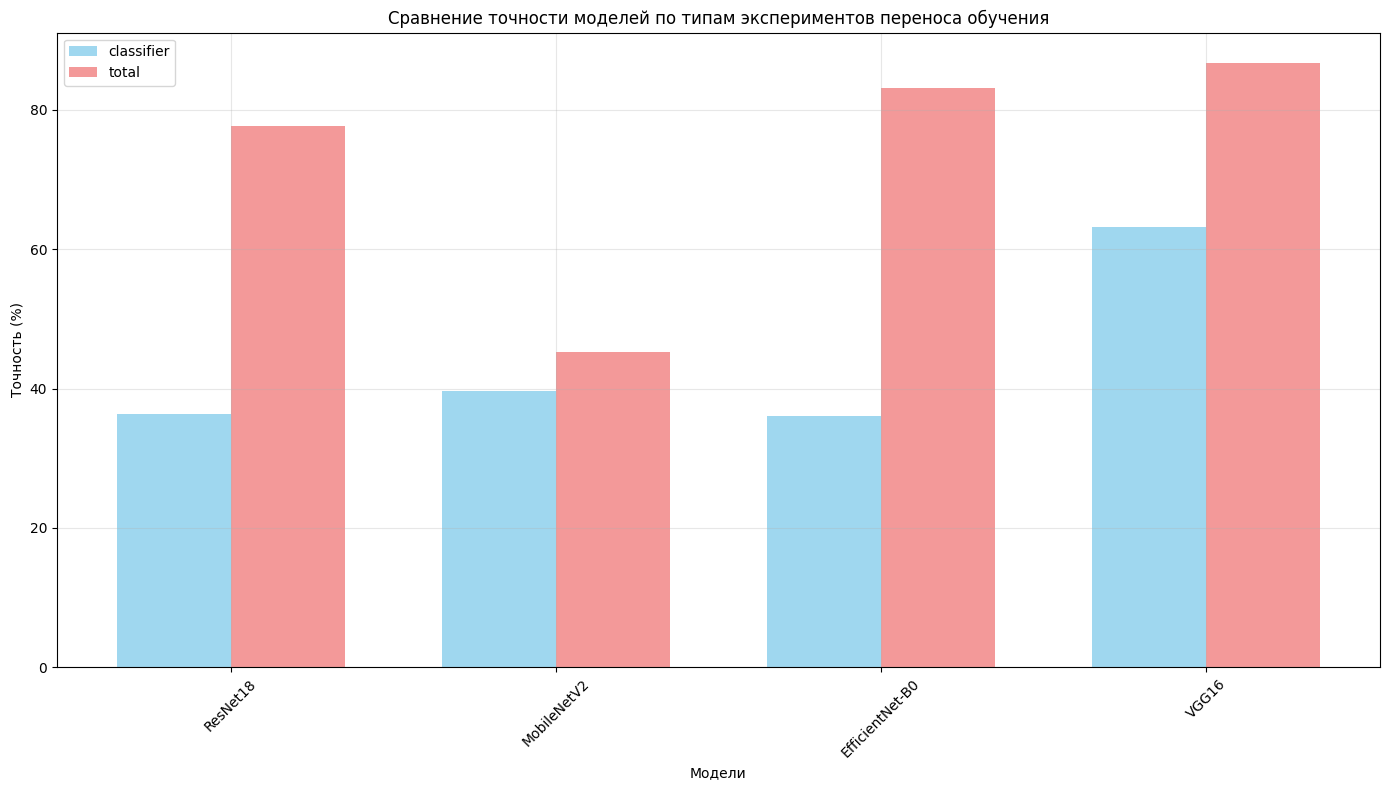

In [68]:
print("\n" + "=" * 60)
print("СРАВНИТЕЛЬНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ")
print("=" * 60)

all_results = experiment1_results + experiment2_results
results_df = pd.DataFrame(all_results)

top_models = results_df.nlargest(4, 'accuracy')

print("\nТоп-4 модели по точности:")
for idx, row in top_models.iterrows():
    print(f"{row['model']} ({row['experiment_type']}): {row['accuracy']:.2f}%")

plt.figure(figsize=(14, 8))
colors = ['skyblue', 'lightcoral']
experiment_types = ['classifier', 'total']

models_list = results_df['model'].unique()
x_pos = np.arange(len(models_list))
width = 0.35

for i, exp_type in enumerate(experiment_types):
    accuracies = []
    for model in models_list:
        result = results_df[(results_df['model'] == model) &
                           (results_df['experiment_type'] == exp_type)]
        if not result.empty:
            accuracies.append(result['accuracy'].values[0])
        else:
            accuracies.append(0)

    plt.bar(x_pos + i * width, accuracies, width, label=exp_type,
            color=colors[i], alpha=0.8)

plt.xlabel('Модели')
plt.ylabel('Точность (%)')
plt.title('Сравнение точности моделей по типам экспериментов переноса обучения')
plt.xticks(x_pos + width/2, models_list, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [64]:
best_result = results_df.loc[results_df['accuracy'].idxmax()]
print("\n" + "=" * 60)
print("ЛУЧШАЯ МОДЕЛЬ")
print("=" * 60)
print(f"Название модели: {best_result['model']}")
print(f"Тип эксперимента: {best_result['experiment_type']}")
print(f"Точность на тестовой выборке: {best_result['accuracy']}%")
print(f"Количество обучаемых параметров: {best_result['trainable_params']:,}")
print(f"Время обучения: {best_result['training_time']} секунд")

if best_result['experiment_type'] == 'classifier':
    print("Параметры обучения:")
    print("  - Алгоритм оптимизации: SGD")
    print("  - Learning rate: 0.1")
    print("  - Инициализация весов: предобученные веса backbone, случайные для классификатора")
else:
    print("Параметры обучения:")
    print("  - Алгоритм оптимизации: SGD")
    print(f"  - Learning rate: {0.1 if best_result['model'] != 'VGG16' else 0.01}")
    print("  - Инициализация весов: предобученные веса для всей сети")



ЛУЧШАЯ МОДЕЛЬ
Название модели: VGG16
Тип эксперимента: total
Точность на тестовой выборке: 86.77%
Количество обучаемых параметров: 134,301,514
Время обучения: 389.76 секунд
Параметры обучения:
  - Алгоритм оптимизации: SGD
  - Learning rate: 0.1
  - Инициализация весов: предобученные веса для всей сети



ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА

Сравнение точности по моделям (%):
experiment_type  classifier  total
model                             
EfficientNet-B0       36.03  83.18
MobileNetV2           39.66  45.28
ResNet18              36.37  77.67
VGG16                 63.18  86.77


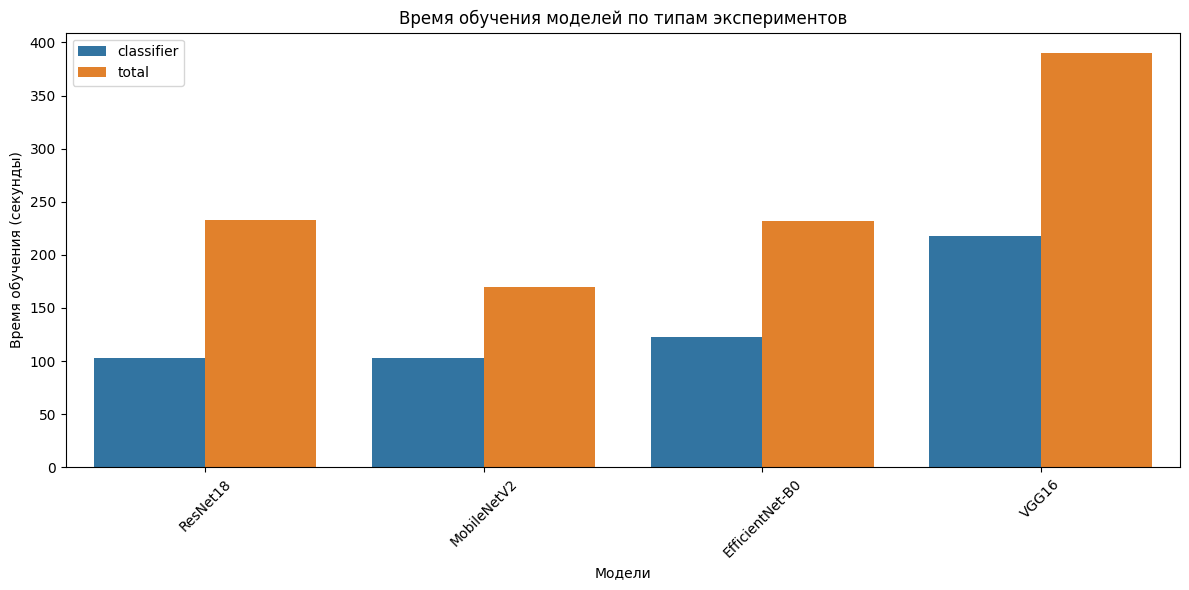

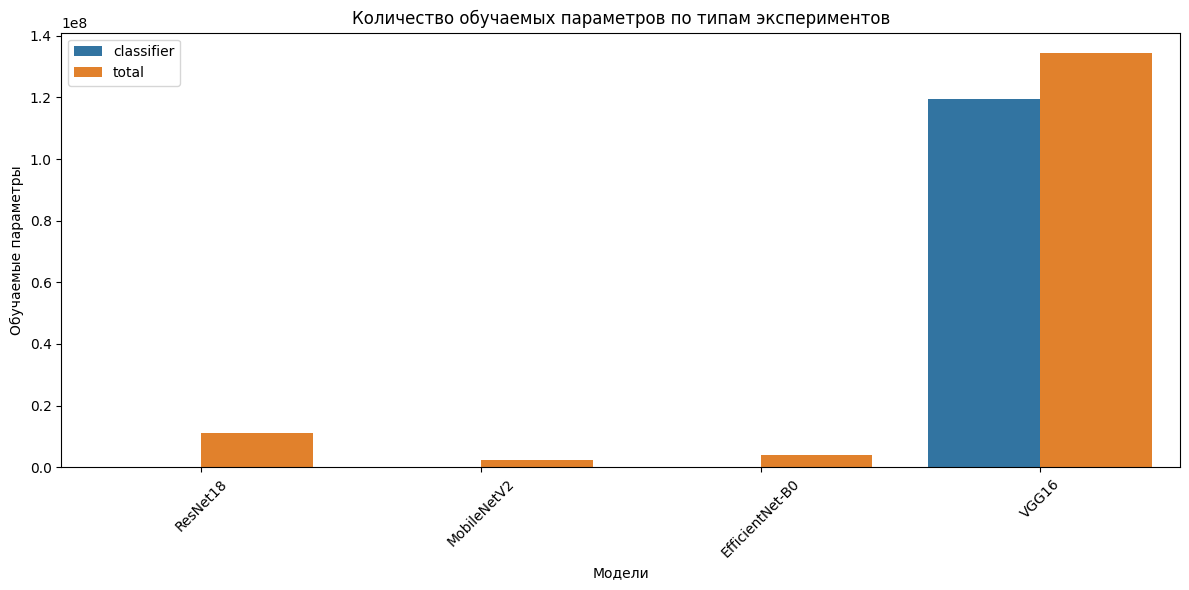

In [65]:
print("\n" + "=" * 60)
print("ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА")
print("=" * 60)

comparison_df = results_df.pivot(index='model', columns='experiment_type', values='accuracy')
print("\nСравнение точности по моделям (%):")
print(comparison_df.round(2))

plt.figure(figsize=(12, 6))
time_df = pd.DataFrame(all_results)
sns.barplot(data=time_df, x='model', y='training_time', hue='experiment_type')
plt.title('Время обучения моделей по типам экспериментов')
plt.xlabel('Модели')
plt.ylabel('Время обучения (секунды)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
param_df = pd.DataFrame(all_results)
sns.barplot(data=param_df, x='model', y='trainable_params', hue='experiment_type')
plt.title('Количество обучаемых параметров по типам экспериментов')
plt.xlabel('Модели')
plt.ylabel('Обучаемые параметры')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()